# 07 - RESUME EXTRACTIF (pipeline v4)

Module 3, *Resumer*. On selectionne dans un livre les `k` phrases qui le
representent le mieux tout en se repetant le moins.

Ce notebook decrit la **v4** du pipeline, celle qu'implemente
`pipeline/summarization.py` et que sert l'application. Elle differe de la v3
sur deux points de conception, et c'est ce qui justifie de le reprendre :

1. **La pertinence est un score hybride** et non plus la seule similarite au
   centre. Elle combine la specificite lexicale (TF-IDF), la centralite
   thematique (TextRank sur le graphe de similarite) et un bonus de longueur.
2. **La diversite de MMR se calcule sur des embeddings CamemBERT** et non sur
   les vecteurs TF-IDF. La raison est explicite : CamemBERT reconnait les
   paraphrases, deux phrases qui disent la meme chose avec des mots differents
   sont proches dans son espace. TF-IDF ne voit que le vocabulaire partage.

Les mesures agregees sur tout le corpus vivent dans `docs/evaluation.md` et se
rejouent avec `scripts/tests_resumes.py`. Ce notebook explique le mecanisme sur
un livre.

## Setup

In [1]:
import sys
from pathlib import Path

# Se deplacer dans le dossier du projet (NE LANCER QU'UNE FOIS)
%cd ../

/data/projets/EVAL_MASTER1/projet_nlp_app


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pipeline import storage
from pipeline.benchmark import preparer_pool
from pipeline.config import EMB_PARAMS, MMR_PARAMS
from pipeline.corpus import charger_corpus, trouver_livre
from pipeline.summarization import (
    bonus_longueur,
    centralite_textrank,
    extraire_phrases,
    formatter_resume,
    mmr,
    resumer_livre,
    score_hybride,
    similarite_au_centre,
    vectoriser_phrases_tfidf,
)

CFG = {
    "figures_dir":    Path("figures"),
    "k_phrases":      MMR_PARAMS["k_phrases"],
    "lambda_default": MMR_PARAMS["lambda_default"],
    "min_df":         MMR_PARAMS["min_df"],
    "ngram_max":      MMR_PARAMS["ngram_max"],
    "poids":          EMB_PARAMS["poids_score"],
}
CFG["figures_dir"].mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

print("poids du score hybride :", CFG["poids"])

poids du score hybride : {'centre': 0.7, 'textrank': 0.2, 'longueur': 0.05}


## Chargement

On charge le corpus **sans les DataFrames** (`with_df=False`), puis on va
chercher le seul dont on a besoin. Les DataFrames annotes pesent environ 7,8 Mo
par livre : en retenir 291 pour n'en demonstrer qu'un couterait 2,2 Go sans
raison.

In [3]:
corpus = charger_corpus(with_df=False)
print(f"{len(corpus)} livres dans le corpus")

Chargement de 291 livres annotes...


    10/291 livres  (110.6s ecoulees,  0.1/s, ~3109s restantes)


    20/291 livres  (110.6s ecoulees,  0.2/s, ~1499s restantes)


    ReadTimeoutError sur annotations/biography/rouquette_louis_frederic/pg70801_lepopee_blanche.parquet, nouvel essai dans 1s (1/4)


    ReadTimeoutError sur annotations/biography/marmont_auguste_frederic_louis_viesse_de_duc_de_raguse/pg30013_memoires_du_marechal_marmont_duc_de_raguse_39.parquet, nouvel essai dans 1s (1/4)


...

   280/291 livres  (309.5s ecoulees,  4.3/s, ~3s restantes)


   290/291 livres  (309.9s ecoulees,  5.1/s, ~0s restantes)


   291/291 livres  (309.9s ecoulees,  5.3/s, ~0s restantes)


  1 override(s) de genre appliques.
  291 livres charges en 309.9s (8 telechargements simultanes)


291 livres dans le corpus


## Livre temoin

On prend un roman connu pour que les phrases selectionnees soient lisibles sans
avoir lu le livre.

In [4]:
# Selection par SLUG et non par recherche textuelle.
#
# `trouver_livre(corpus, "zola")` marchait sur le corpus de 26 livres. A 291
# il ne marche plus : la recherche matche aussi le TITRE, et le premier
# resultat devient « Quelques Ecrivains Francais : Flaubert, Zola, Hugo... »
# d'Emile Hennequin, qui est un essai critique SUR Zola et non un roman DE
# Zola. Un essai de critique litteraire fait une demonstration nettement
# moins parlante qu'un roman, ou les phrases retenues racontent quelque
# chose de reconnaissable.
#
# C'est un exemple utile du genre de piege que le passage a l'echelle fait
# apparaitre : un code qui marchait par chance sur un petit corpus.
SLUG_TEMOIN = "pg5711_germinal"

livre = next(c for c in corpus if c["livre_slug"] == SLUG_TEMOIN)
print(f"Livre temoin : {livre['auteur']} -- {livre['livre']} ({livre['genre']})")
print(f"{livre['n_tokens']:,} tokens, {livre['n_phrases']:,} phrases")

# Le DataFrame annote de ce livre uniquement.
df = storage.get_parquet(livre["cle"])
print(f"DataFrame charge : {df.shape}")

Livre temoin : Zola Emile -- Germinal (novel)
212,183 tokens, 10,375 phrases


DataFrame charge : (212183, 9)


## 1. Extraction des phrases candidates

Toutes les phrases ne sont pas resumables. `extraire_phrases` applique quatre
filtres, dont les seuils sont dans `MMR_PARAMS` :

- **longueur minimale** (`min_tokens_phrase`), en tokens informatifs. A 12 le
  filtre eliminait 70 a 90 % des phrases du corpus, soit tous les dialogues et
  les phrases d'action courtes ; il est descendu a 8.
- **longueur maximale** (`max_tokens_phrase`), qui ecarte les paragraphes mal
  segmentes.
- **densite** (`min_densite`), le ratio de tokens informatifs sur le total.
- **ratio de noms propres** (`max_propn_ratio`), qui ecarte les enumerations de
  personnages.

In [5]:
phrases = extraire_phrases(df, champ_termes="lemma")

n_total = df["sent_id"].nunique()
print(f"{n_total:,} phrases dans le livre")
print(f"{len(phrases):,} retenues comme candidates "
      f"({len(phrases) / n_total * 100:.1f} %)")

longueurs = [len(p["termes"]) for p in phrases]
print(f"longueur des candidates : mediane {int(np.median(longueurs))} termes "
      f"informatifs, de {min(longueurs)} a {max(longueurs)}")

print("\nTrois candidates au hasard :")
rng = np.random.default_rng(42)
for i in rng.choice(len(phrases), 3, replace=False):
    print(f"  - {phrases[i]['texte'][:150]}")

10,375 phrases dans le livre
3,597 retenues comme candidates (34.7 %)
longueur des candidates : mediane 12 termes informatifs, de 8 a 59

Trois candidates au hasard :
  - Négrel se sentait blêmir, lui aussi, très brave d'ordinaire, saisi là d'une épouvante supérieure à sa volonté, une de ces épouvantes qui soufflent de 
  - , il se rappelait la rue, des détails lui revenaient: le linge sale au milieu de la boutique, et des ivresses qui empuantissaient la maison, et des gi
  - mais ils blanchissaient, ils s'effiloquaient, plus minces, d'une transparence brouillée d'eau trouble sur la face de la lune;


## 2. Les trois composantes de la pertinence

Le score hybride combine trois signaux normalises. On les calcule un par un
pour voir ce que chacun apporte.

In [6]:
# Composante 1 : specificite lexicale, via TF-IDF sur les phrases.
matrice_tfidf = vectoriser_phrases_tfidf(
    phrases, ngram_max=CFG["ngram_max"], min_df=CFG["min_df"],
)
s_centre = similarite_au_centre(matrice_tfidf)
print(f"matrice TF-IDF des phrases : {matrice_tfidf.shape}")

# Composantes 2 et 3 : embeddings CamemBERT, puis TextRank et longueur.
# `preparer_pool` fait l'extraction et l'encodage en une fois, c'est ce
# qu'utilise le benchmark.
phrases_pool, embeddings = preparer_pool(df, champ_termes="lemma")
print(f"embeddings CamemBERT       : {embeddings.shape}")

s_textrank = centralite_textrank(embeddings)
s_longueur = bonus_longueur(phrases)

composantes = pd.DataFrame({
    "centre":   s_centre,
    "textrank": s_textrank,
    "longueur": s_longueur,
})
print()
print(composantes.describe().round(4))

matrice TF-IDF des phrases : (3597, 3771)


/data/projets/EVAL_MASTER1/projet_nlp_app/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


embeddings CamemBERT       : (3597, 768)



          centre   textrank   longueur
count  3597.0000  3597.0000  3597.0000
mean      0.0928     0.0003     0.7919
std       0.0304     0.0002     0.1757
min       0.0135     0.0000     0.5250
25%       0.0703     0.0001     0.6000
50%       0.0910     0.0002     0.8000
75%       0.1123     0.0004     1.0000
max       0.2126     0.0013     1.0000


### Les composantes sont-elles redondantes ?

Si elles mesuraient la meme chose, en combiner trois n'aurait pas de sens. Une
correlation faible justifie le score hybride ; une correlation forte le
condamnerait.

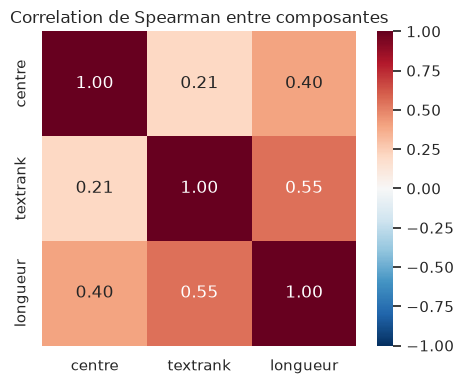

          centre  textrank  longueur
centre     1.000     0.211     0.401
textrank   0.211     1.000     0.552
longueur   0.401     0.552     1.000


In [7]:
correlations = composantes.corr(method="spearman")

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation de Spearman entre composantes")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "composantes_correlation.png")
plt.show()

print(correlations.round(3))

## 3. Le score hybride

`score_hybride` normalise chaque composante puis les pondere. Les poids par
defaut sont dans `EMB_PARAMS["poids_score"]`.

Le poids TextRank vaut **0,20** et non 0,30, et c'est une decision mesuree : a
0,30 le resume produit etait *plus* redondant que le simple top-k TF-IDF, ce
que MMR est cense minimiser. TextRank est de loin la plus redondante des trois
composantes, et le terme de diversite ne rattrapait pas ce qu'elle introduisait
dans la pertinence.

La somme des poids ne vaut pas 1 et n'a pas a valoir 1 : seul le score relatif
entre phrases est utilise.

In [8]:
scores = score_hybride(phrases, matrice_tfidf, embeddings, poids=CFG["poids"])

print(f"score hybride : min {scores.min():.4f}, max {scores.max():.4f}, "
      f"moyenne {scores.mean():.4f}")
print("\nLes 5 phrases les mieux notees (avant MMR) :")
for rang, i in enumerate(np.argsort(-scores)[:5], 1):
    print(f"  [{rang}] {scores[i]:.4f}  {phrases[i]['texte'][:120]}")

score hybride : min 0.0100, max 0.8683, moyenne 0.3437

Les 5 phrases les mieux notees (avant MMR) :
  [1] 0.8683  Puis, les jeunes gens servis, il se planta sur la porte pour les regarder s'éloigner dans le crépuscule; et, comme sa fe
  [2] 0.8430  Le peu qui restait de sa popularité s'en était allé au vent de la fusillade, il ne passait plus sans rencontrer des rega
  [3] 0.8399  tandis que, derrière, le briquet faisait à chacun une bosse. Vêtus de toile mince, ils grelottaient de froid, sans se hâ
  [4] 0.8056  Justement, à la Fourche-aux-Boeufs, il se souvint qu'il avait pris là le commandement de la bande, le matin du saccage d
  [5] 0.7973  Mais lui, remuait, la saisissait à pleins bras, dans les convulsions de l'agonie, comme s'il eût voulu la reprendre, ain


## 4. Selection MMR, et effet de lambda

MMR choisit gloutonnement : a chaque tour il prend la phrase qui maximise

    lambda * pertinence - (1 - lambda) * max(similarite aux deja choisies)

`lambda = 1` desactive le terme de diversite et degenere en simple top-k sur le
score hybride. Plus lambda baisse, plus la diversite pese.

In [9]:
for lam in [0.3, 0.6, 1.0]:
    indices = mmr(embeddings, scores, k=5, lambda_=lam)
    print(f"\n--- lambda = {lam} ---")
    for rang, i in enumerate(indices, 1):
        texte = phrases[i]["texte"]
        if len(texte) > 110:
            texte = texte[:107] + "..."
        print(f"  [{rang}] {texte}")


--- lambda = 0.3 ---
  [1] Puis, les jeunes gens servis, il se planta sur la porte pour les regarder s'éloigner dans le crépuscule; et...
  [2] la voyaient parfaite, point trop grasse, jamais assez bien nourrie.
  [3] vous êtes bien tous les mêmes, vous vous laisseriez aplatir le crâne, plutôt que de lâcher la veine, pour m...
  [4] c'était naturel, on a une fille pour qu'elle travaille... Mais voilà, nous avons été trop bons, nous n'auri...
  [5] Allez, allez, vous aurez beau dire, mon mari sait bien pourquoi monsieur Dansaert était chez nous.

--- lambda = 0.6 ---
  [1] Puis, les jeunes gens servis, il se planta sur la porte pour les regarder s'éloigner dans le crépuscule; et...
  [2] Parfois quand la flamme des lampes pâlissait et bleuissait davantage, on songeait à lui, un mineur mettait ...
  [3] de rester jusqu'au bout avec les amis, quitte à crever tous ensemble. Désespéré, Étienne rentra dans la fou...
  [4] Justement, à la Fourche-aux-Boeufs, il se souvint qu'il avait pris là

## 5. Mesures : pertinence contre redondance

Deux mesures intrinseques, calculees sur les phrases selectionnees :

- **pertinence** : score hybride moyen des phrases retenues.
- **redondance** : similarite CamemBERT moyenne entre paires de phrases
  retenues, sur le triangle superieur strict. Plus c'est bas, mieux c'est.

Elles doivent varier en sens inverse quand lambda bouge. Si ce n'etait pas le
cas, le terme de diversite ne servirait a rien.

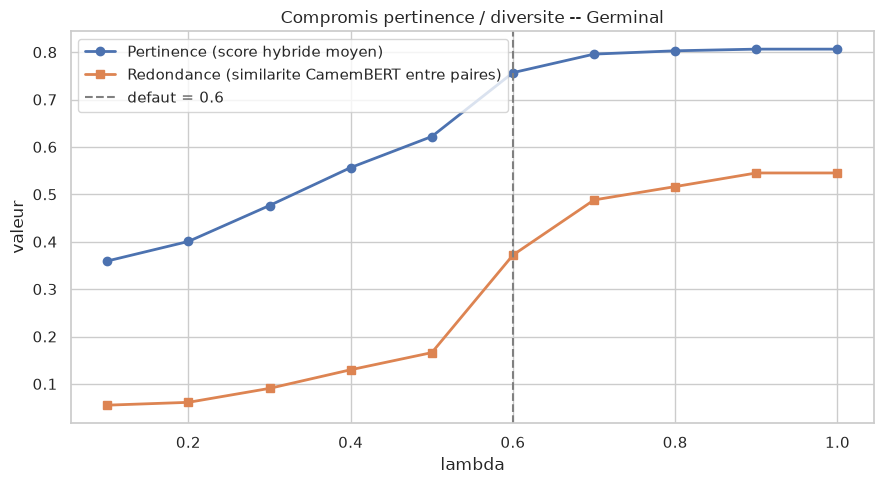

 lambda  pertinence  redondance
    0.1      0.3593      0.0551
    0.2      0.4006      0.0611
    0.3      0.4764      0.0906
    0.4      0.5564      0.1298
    0.5      0.6219      0.1660
    0.6      0.7567      0.3718
    0.7      0.7958      0.4882
    0.8      0.8028      0.5163
    0.9      0.8063      0.5451
    1.0      0.8063      0.5451


In [10]:
def mesurer(indices):
    """Pertinence moyenne et redondance moyenne d'une selection."""
    pertinence = float(scores[indices].mean())
    if len(indices) > 1:
        E = embeddings[indices]
        sims = E @ E.T
        ii, jj = np.triu_indices_from(sims, k=1)
        redondance = float(sims[ii, jj].mean())
    else:
        redondance = 0.0
    return pertinence, redondance


mesures = []
for lam in np.linspace(0.1, 1.0, 10):
    indices = mmr(embeddings, scores, k=CFG["k_phrases"], lambda_=float(lam))
    pert, red = mesurer(indices)
    mesures.append({"lambda": float(lam), "pertinence": pert, "redondance": red})

mesures_df = pd.DataFrame(mesures)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mesures_df["lambda"], mesures_df["pertinence"], "o-",
        label="Pertinence (score hybride moyen)", linewidth=2)
ax.plot(mesures_df["lambda"], mesures_df["redondance"], "s-",
        label="Redondance (similarite CamemBERT entre paires)", linewidth=2)
ax.axvline(CFG["lambda_default"], color="grey", linestyle="--",
           label=f"defaut = {CFG['lambda_default']}")
ax.set_xlabel("lambda")
ax.set_ylabel("valeur")
ax.set_title(f"Compromis pertinence / diversite -- {livre['livre']}")
ax.legend()
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "mmr_lambda.png")
plt.show()

print(mesures_df.round(4).to_string(index=False))

## 6. Visualisation 2D des phrases selectionnees

On projette les embeddings CamemBERT de toutes les phrases candidates dans le
plan PCA, et on marque celles que MMR retient. Une bonne selection doit etre
**etalee** dans le nuage plutot que groupee dans un coin.

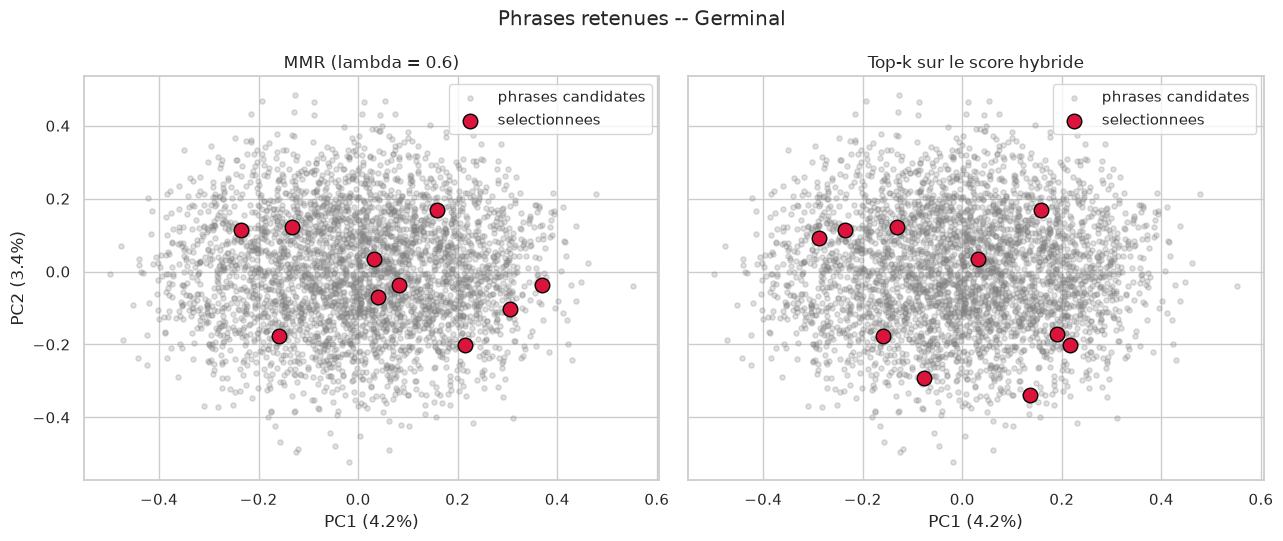

variance expliquee par les 2 axes : 7.7%


In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
phrases_2d = pca.fit_transform(embeddings)

indices_sel = mmr(embeddings, scores, k=CFG["k_phrases"],
                  lambda_=CFG["lambda_default"])
indices_topk = np.argsort(-scores)[:CFG["k_phrases"]]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
for ax, (titre, idx) in zip(axes, [
    (f"MMR (lambda = {CFG['lambda_default']})", indices_sel),
    ("Top-k sur le score hybride", indices_topk),
]):
    ax.scatter(phrases_2d[:, 0], phrases_2d[:, 1],
               s=14, alpha=0.25, color="grey", label="phrases candidates")
    ax.scatter(phrases_2d[idx, 0], phrases_2d[idx, 1],
               s=110, color="crimson", edgecolor="black",
               zorder=3, label="selectionnees")
    ax.set_title(titre)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.legend()
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.suptitle(f"Phrases retenues -- {livre['livre']}")
plt.tight_layout()
plt.savefig(CFG["figures_dir"] / "mmr_phrases_2d.png")
plt.show()

print(f"variance expliquee par les 2 axes : "
      f"{pca.explained_variance_ratio_[:2].sum():.1%}")

## 7. Visualisation 3D autonome (HTML)

La PCA 2D ne capture qu'une fraction de la variance. On exporte une projection
3D interactive pour pouvoir tourner autour du nuage.

In [12]:
import plotly.graph_objects as go

pca3 = PCA(n_components=3, random_state=42)
phrases_3d = pca3.fit_transform(embeddings)

est_selectionnee = np.zeros(len(phrases), dtype=bool)
est_selectionnee[indices_sel] = True

survol = [p["texte"][:160] for p in phrases]

fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(
    x=phrases_3d[~est_selectionnee, 0],
    y=phrases_3d[~est_selectionnee, 1],
    z=phrases_3d[~est_selectionnee, 2],
    mode="markers", name="candidates",
    marker=dict(size=2.5, color="lightgrey", opacity=0.6),
    text=[t for t, s in zip(survol, est_selectionnee) if not s],
    hoverinfo="text",
))
fig3d.add_trace(go.Scatter3d(
    x=phrases_3d[est_selectionnee, 0],
    y=phrases_3d[est_selectionnee, 1],
    z=phrases_3d[est_selectionnee, 2],
    mode="markers", name="selectionnees par MMR",
    marker=dict(size=6, color="crimson"),
    text=[t for t, s in zip(survol, est_selectionnee) if s],
    hoverinfo="text",
))
fig3d.update_layout(
    title=f"Phrases de {livre['livre']} projetees en 3D "
          f"(variance {pca3.explained_variance_ratio_.sum():.1%})",
    height=650, margin=dict(l=0, r=0, t=40, b=0),
)
fig3d.write_html(CFG["figures_dir"] / "mmr_phrases_3d.html")
print(f"exporte : {CFG['figures_dir'] / 'mmr_phrases_3d.html'}")
fig3d.show()

exporte : figures/mmr_phrases_3d.html


## 8. Le pipeline bout en bout

`resumer_livre` enchaine tout ce qui precede en un appel. On verifie qu'il
retombe bien sur la meme selection que le montage manuel des sections
precedentes : si les deux divergent, c'est que le notebook decrit autre chose
que ce que le code fait.

In [13]:
selection = resumer_livre(
    df, champ_termes="lemma",
    k=CFG["k_phrases"], lambda_=CFG["lambda_default"],
)

indices_bout_en_bout = [p["sent_id"] for p in selection]
indices_manuels = [phrases[i]["sent_id"] for i in indices_sel]

identiques = indices_bout_en_bout == indices_manuels
print(f"selection identique au montage manuel : {identiques}")
if not identiques:
    print(f"  bout-en-bout : {indices_bout_en_bout}")
    print(f"  manuel       : {indices_manuels}")

selection identique au montage manuel : True


## 9. Apercu du resume final

In [14]:
resume = formatter_resume(
    selection,
    livre=livre["livre"], auteur=livre["auteur"], genre=livre["genre"],
    k=CFG["k_phrases"], lambda_=CFG["lambda_default"],
)
print(resume)

Germinal
Zola Emile  (novel)
Resume extractif - 10 phrases - MMR lambda=0.6

[ 1] Puis, les jeunes gens servis, il se planta sur la porte pour les regarder s'éloigner dans le crépuscule; et, comme sa femme venait d'une voix timide lui demander un renseignement, il tomba sur elle, l'injuria, cria qu'il ferait se repentir un jour le sale monde qui manquait de reconnaissance, lorsque tous auraient dû être par terre, à lui lécher les pieds. Sur la route, le grand Chaval accompagnait Catherine.

[ 2] Parfois quand la flamme des lampes pâlissait et bleuissait davantage, on songeait à lui, un mineur mettait la tête contre la veine, pour écouter le petit bruit du gaz, un bruit de bulles d'air bouillonnant à chaque fente. Mais la menace continuelle étaient les éboulements: car, outre l'insuffisance des boisages, toujours bâclés trop vite, les terres ne tenaient pas, détrempées par les eaux.

[ 3] de rester jusqu'au bout avec les amis, quitte à crever tous ensemble. Désespéré, Étienne rentra dan

## 10. Et sur tout le corpus ?

La generation des 291 resumes et leur upload sur S3 ne se font **pas** ici mais
dans `scripts/rebuild_artifacts.py`. La division est volontaire : un notebook
explique un mecanisme sur un cas, un script produit un artefact de facon
reproductible et rejouable.

On se contente de relire ce que le script a produit.

In [15]:
from pipeline.config import PREFIXES

resumes_s3 = storage.list_objects(PREFIXES["summaries"], suffix=".txt")
print(f"{len(resumes_s3)} resumes presents sur S3 pour "
      f"{len(corpus)} livres du corpus")

# Apercu d'un autre livre, pour verifier que ce n'est pas un cas isole.
autre = storage.get_text(resumes_s3[0]["Key"])
print("\n" + "\n".join(autre.splitlines()[:8]))

291 resumes presents sur S3 pour 291 livres du corpus

En Avion Vers Le Pole Nord
Amundsen Roald  (adventure)
Resume extractif - 10 phrases - MMR lambda=0.6

[ 1] Chenal ouvert par un vapeur à travers la banquise recouvrant le fjord pour permettre aux navires de l'expédition d'arriver à Ny Aalesund 30 Spitzberg.-- Débarquement de la coque du _ N-25 _ à Ny Aalesund 46 Spitzberg.-- Le débarquement des hydravions à la baie du Roi 62 Spitzberg.-- La mise en place des hélices 78 Spitzberg.-- L'envol du _ N-24 _ sur la glace recouvrant la baie du Roi 94 Spitzberg.-- Face à l'océan Glacial arctique, le cap Nord près duquel Amundsen amérit, au retour de son envol vers le Pôle 109 Les deux avions sur la banquise à 254 kilomètres du Pôle 110 Amundsen et ses compagnons déblayant la banquise pour mettre le _ N-25 _ en sécurité sur un grand glaçon 126

[ 2] De brume nous n'en avions pas encore vu et, sans les renseignements fournis par les observations du Farm, pendant les années 1893 - 1896, sur l

## Conclusions

**1. Les trois composantes mesurent bien des choses différentes, sur ce
livre.** Sur Germinal, `centre` et `textrank` ne sont corrélées qu'à 0,21 en
Spearman, `centre` et `longueur` à 0,40. C'est ce qui justifie de les combiner
plutôt que d'en garder une seule.

Une réserve importante : **ce chiffre dépend du livre**. Sur un essai critique
testé pendant la mise au point de ce notebook, la même corrélation
`centre`/`textrank` montait à 0,59. La spécificité lexicale et la centralité
thématique convergent sur un texte argumentatif, où les phrases importantes
reprennent le vocabulaire de la thèse, et divergent sur un roman, où une phrase
peut être centrale narrativement sans porter le vocabulaire dominant. Une seule
mesure sur un seul livre ne suffit donc pas à trancher, et la conclusion ne
vaut ici que pour la fiction.

**2. Pertinence et redondance varient en sens inverse avec lambda**, ce qui est
le comportement attendu et rend le paramètre utile. La courbe sature à partir
de `lambda ≈ 0,8` : au-delà, le terme de diversité ne pèse plus assez pour
changer la sélection, et `lambda = 0,9` donne exactement le même résultat que
`lambda = 1,0`.

**3. `lambda = 0,6` est le seul réglage testé qui batte le top-k naïf sur les
deux critères à la fois**, mesuré sur le corpus entier et non sur ce seul
livre. À 0,5 la redondance est meilleure mais la couverture passe sous la
baseline ; à 0,8 c'est l'inverse.

**4. MMR bat le top-k naïf sur les deux critères**, vérifié par test des signes
apparié sur 291 livres : redondance 196/291 (`p = 2,1e-9`) et couverture
179/291 (`p = 2,5e-5`). Cette conclusion a changé avec la taille du corpus. À
26 livres, la couverture donnait 17/26 et `p = 0,169`, soit une parité non
concluante. La proportion était déjà là, la puissance statistique manquait.

**5. Significatif ne veut pas dire important.** L'avantage de couverture vaut
3 % en relatif. Les intervalles de confiance de `scripts/tests_resumes.py` sont
là pour empêcher de lire un `p` très petit comme un écart très grand.

**6. Réserve de méthode.** Redondance et couverture restent des proxys
intrinsèques. Ils ne mesurent ni la lisibilité ni la cohérence narrative, qui
étaient les motivations qualitatives de la refonte v4. Un jugement humain sur
quelques livres trancherait ce que ces deux chiffres ne tranchent pas.